## Visualization of the CS336 Model

In [1]:
!uv pip install --quiet torchview
import torch
import cs336_basics.ron_transformer_lm as ron_transformer_lm
from torchview import draw_graph

In [27]:
import cs336_basics.ron_transformer_lm as ron_transformer_lm

# from the 7.2 section
device='cpu'
vocab_size = 10000
context_length = 256
d_model = 512
d_ff = 1344
rope_theta = 10000
num_layers = 4
num_heads = 16
batch_size = 15 # fits in 6GB Nvidia 2060
token_length = context_length - 1

tlm = ron_transformer_lm.TransformerLM(
    d_model=d_model,
    num_heads=num_heads,
    d_ff = d_ff,
    max_seq_len=context_length,
    theta=rope_theta,
    vocab_size=vocab_size,
    context_length=context_length,
    num_layers=num_layers
)
tlm


TransformerLM(
  (embed): Embedding()
  (xform): ModuleList(
    (0-3): 4 x TransformerBlock(
      (cmsawr): CausalMultiheadSelfAttentionWithRope(
        (q_proj): Linear()
        (k_proj): Linear()
        (v_proj): Linear()
        (o_proj): Linear()
        (rope): RoPE()
      )
      (ln1): RMSNorm()
      (ln2): RMSNorm()
      (ffn): SwiGLU(
        (w1): Linear()
        (w2): Linear()
        (w3): Linear()
      )
    )
  )
  (norm): RMSNorm()
  (head): Linear()
)

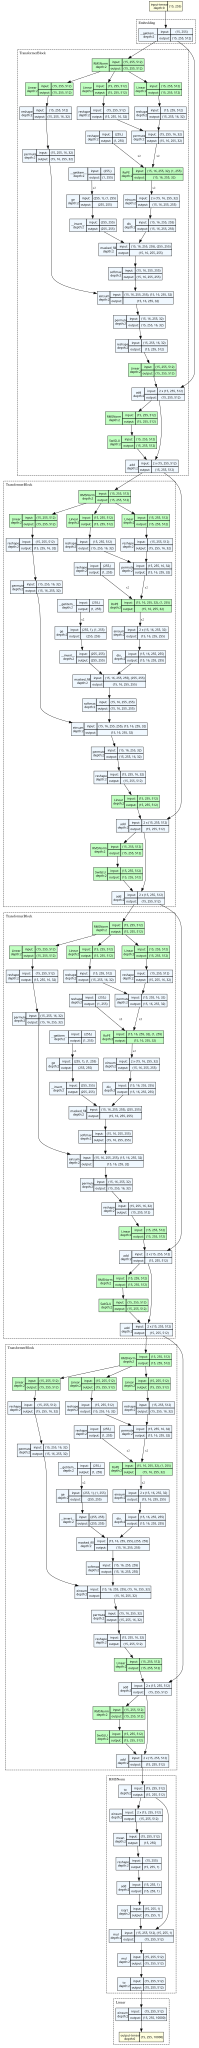

In [28]:
from torchview import draw_graph

# device='meta' -> no memory is consumed for visualization
model_graph = draw_graph(tlm,                          
                        input_data = torch.randint(0,vocab_size, (batch_size, token_length)),
                        device='meta',
                        depth=2,
                        expand_nested=True,
                        hide_inner_tensors=True,
                        roll=True,
                        hide_module_functions=False,
)
model_graph.visual_graph

## More detail

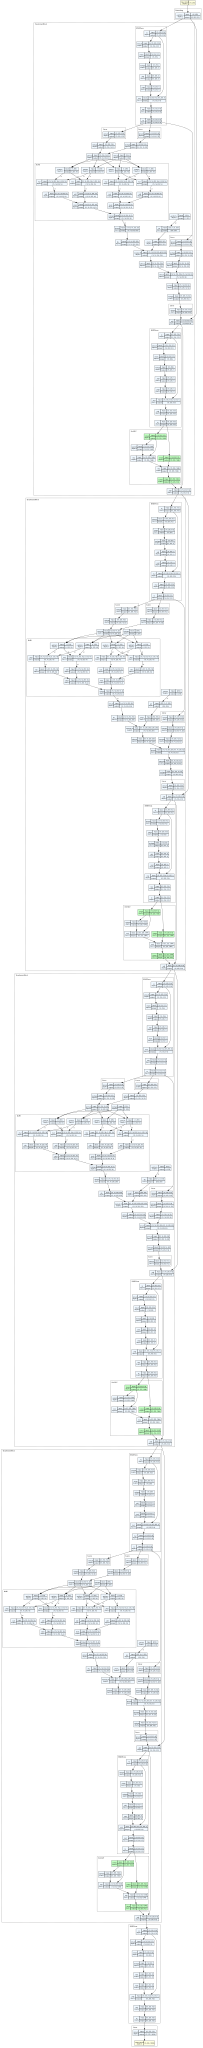

In [29]:

# device='meta' -> no memory is consumed for visualization
model_graph = draw_graph(tlm,                          
                        input_data = torch.randint(0,vocab_size, (batch_size, token_length)),
                        device='meta',
                        depth=3,
                        expand_nested=True,
                        hide_inner_tensors=True,
                        roll=True,
                        hide_module_functions=False,
)

model_graph.visual_graph

## Shorter

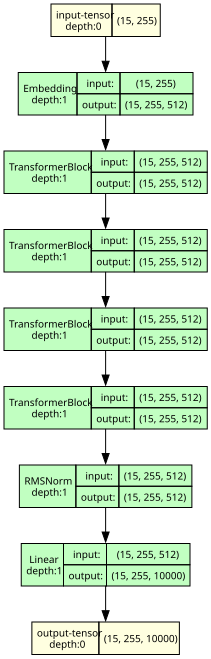

In [32]:

# device='meta' -> no memory is consumed for visualization
model_graph = draw_graph(tlm,                          
                        input_data = torch.randint(0,vocab_size, (batch_size, token_length)),
                        device='meta',
                        depth=1,
                        expand_nested=True,
                        hide_inner_tensors=True,
                        roll=True,
                        hide_module_functions=False,
)

model_graph.visual_graph